In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
dataset = pd.read_csv(
    INTERIM_DIR /
    "earthquake_ground_motion_integrated.csv"
)

print("Shape:", dataset.shape)
print(
    "Unique earthquakes:",
    dataset["event_id"].nunique()
)

display(dataset.head())

Shape: (2912739, 15)
Unique earthquakes: 40


,grid_lon,grid_lat,PGA,PGV,MMI,PSA03,PSA10,PSA30,event_id,magnitude,event_lat,event_lon,epicentral_distance_km,hypocentral_distance_km,event_depth
0,69.3004,38.2842,0.40,0.17,2.54,0.71,0.18,0.03,us10002mft,5.5,36.68,71.3,250.885571,315.316619,191.0
1,69.3171,38.2842,0.41,0.18,2.57,0.74,0.19,0.03,us10002mft,5.5,36.68,71.3,249.851709,314.494636,191.0
2,69.3337,38.2842,0.40,0.16,2.53,0.71,0.17,0.03,us10002mft,5.5,36.68,71.3,248.828424,313.682299,191.0
3,69.3504,38.2842,0.38,0.15,2.46,0.68,0.16,0.03,us10002mft,5.5,36.68,71.3,247.803445,312.869857,191.0
4,69.3671,38.2842,0.40,0.16,2.50,0.71,0.17,0.03,us10002mft,5.5,36.68,71.3,246.783004,312.062255,191.0


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 2912739 entries, 0 to 2912738
Data columns (total 15 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   grid_lon                 float64
 1   grid_lat                 float64
 2   PGA                      float64
 3   PGV                      float64
 4   MMI                      float64
 5   PSA03                    float64
 6   PSA10                    float64
 7   PSA30                    float64
 8   event_id                 str    
 9   magnitude                float64
 10  event_lat                float64
 11  event_lon                float64
 12  epicentral_distance_km   float64
 13  hypocentral_distance_km  float64
 14  event_depth              float64
dtypes: float64(14), str(1)
memory usage: 333.3 MB


In [5]:
missing = pd.DataFrame({
    "missing_count": dataset.isna().sum(),
    "missing_percent": (
        dataset.isna().mean() * 100
    )
})

display(
    missing[
        missing["missing_count"] > 0
    ].sort_values(
        "missing_count",
        ascending=False
    )
)

,missing_count,missing_percent


In [6]:
event_summary = (
    dataset
    .groupby("event_id")
    .agg(
        magnitude=("magnitude", "first"),
        depth_km=("event_depth", "first"),
        event_lat=("event_lat", "first"),
        event_lon=("event_lon", "first"),
        observations=("event_id", "size"),
        max_pga=("PGA", "max"),
        mean_pga=("PGA", "mean"),
        max_pgv=("PGV", "max"),
        mean_pgv=("PGV", "mean"),
        max_mmi=("MMI", "max")
    )
    .reset_index()
)

print(
    "Events:",
    len(event_summary)
)

display(event_summary)

Events: 40


,event_id,magnitude,depth_km,event_lat,event_lon,observations,max_pga,mean_pga,max_pgv,mean_pgv,max_mmi
0,b000fzn7,5.1,10.70,19.25,95.74,54948,3.59,0.245518,2.25,0.175509,4.27
1,b000g112,5.6,102.00,36.45,71.47,46754,4.61,1.406874,2.59,0.652961,4.27
2,b000hdu8,5.1,10.00,37.51,95.79,46031,2.16,0.275323,1.43,0.191883,3.99
3,b000ktbm,5.4,34.32,26.41,93.65,52056,2.99,0.352068,2.48,0.309949,4.27
4,b000l2rk,5.5,10.26,12.40,95.15,56635,26.96,0.684271,17.15,0.472849,6.69
5,b000l4ju,5.5,15.61,5.42,92.82,57840,26.91,0.667597,17.11,0.462362,6.68
6,b000qy82,6.0,47.23,18.20,88.04,123823,10.13,1.850260,3.45,1.078885,5.23
7,b000ry7u,5.3,12.00,14.36,93.09,56394,21.42,0.482583,11.78,0.292971,6.21
8,b000ryuh,5.8,10.00,12.43,95.20,56635,29.01,0.906641,20.82,0.690931,6.90
9,b000sfrw,5.4,52.00,27.30,65.75,51574,4.07,0.915747,1.70,0.411705,4.04


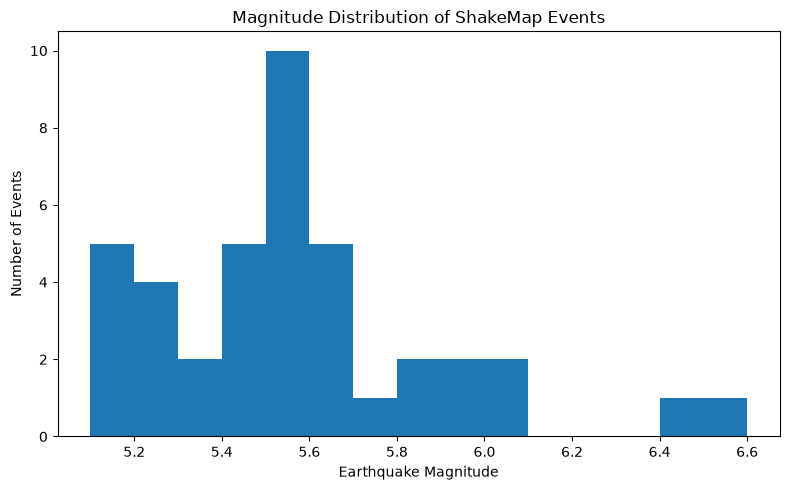

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(
    event_summary["magnitude"],
    bins=15
)

plt.xlabel("Earthquake Magnitude")
plt.ylabel("Number of Events")
plt.title("Magnitude Distribution of ShakeMap Events")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "magnitude_distribution.png",
    dpi=200
)

plt.show()

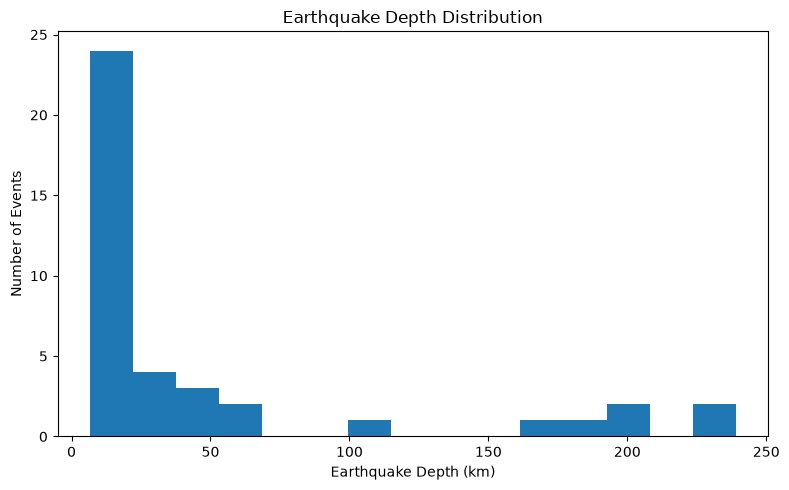

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(
    event_summary["depth_km"],
    bins=15
)

plt.xlabel("Earthquake Depth (km)")
plt.ylabel("Number of Events")
plt.title("Earthquake Depth Distribution")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "depth_distribution.png",
    dpi=200
)

plt.show()

In [9]:
ground_motion_columns = [
    "PGA",
    "PGV",
    "MMI",
    "PSA03",
    "PSA10",
    "PSA30"
]

display(
    dataset[
        ground_motion_columns
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
PGA,2912739.0,0.596749,1.239956,0.00,0.10,0.28,0.69,90.17
PGV,2912739.0,0.398947,0.739707,0.01,0.10,0.21,0.46,41.44
MMI,2912739.0,2.607086,0.735919,1.00,2.21,2.65,3.08,7.74
PSA03,2912739.0,1.226700,2.264547,0.01,0.26,0.68,1.50,139.19
PSA10,2912739.0,0.441829,0.748941,0.01,0.13,0.24,0.51,45.52
PSA30,2912739.0,0.098189,0.158961,0.00,0.03,0.05,0.10,7.70


In [11]:
sample_per_event = 5000

balanced_sample = (
    dataset
    .groupby("event_id", group_keys=False)
    .sample(
        n=sample_per_event,
        random_state=42
    )
    .reset_index(drop=True)
)

print(
    "Balanced sample:",
    balanced_sample.shape
)

print(
    "Events:",
    balanced_sample["event_id"].nunique()
)

Balanced sample: (200000, 15)
Events: 40


In [12]:
correlation_columns = [
    "magnitude",
    "event_depth",
    "epicentral_distance_km",
    "hypocentral_distance_km",
    "PGA",
    "PGV",
    "MMI",
    "PSA03",
    "PSA10",
    "PSA30"
]

correlation_matrix = (
    balanced_sample[
        correlation_columns
    ].corr()
)

display(correlation_matrix)

,magnitude,event_depth,epicentral_distance_km,hypocentral_distance_km,PGA,PGV,MMI,PSA03,PSA10,PSA30
magnitude,1.000000,0.127383,0.221763,0.301112,0.205506,0.324883,0.389909,0.238805,0.387493,0.510193
event_depth,0.127383,1.000000,-0.195260,0.263631,0.167090,-0.039204,0.060721,0.103875,-0.048423,-0.102810
epicentral_distance_km,0.221763,-0.195260,1.000000,0.885635,-0.397077,-0.302237,-0.674020,-0.396461,-0.272726,-0.175052
hypocentral_distance_km,0.301112,0.263631,0.885635,1.000000,-0.305694,-0.314225,-0.633066,-0.334892,-0.288259,-0.216840
PGA,0.205506,0.167090,-0.397077,-0.305694,1.000000,0.897238,0.617643,0.982479,0.879187,0.739185
PGV,0.324883,-0.039204,-0.302237,-0.314225,0.897238,1.000000,0.649565,0.947687,0.990779,0.932702
MMI,0.389909,0.060721,-0.674020,-0.633066,0.617643,0.649565,1.000000,0.657470,0.659339,0.626707
PSA03,0.238805,0.103875,-0.396461,-0.334892,0.982479,0.947687,0.657470,1.000000,0.933209,0.812357
PSA10,0.387493,-0.048423,-0.272726,-0.288259,0.879187,0.990779,0.659339,0.933209,1.000000,0.956456
PSA30,0.510193,-0.102810,-0.175052,-0.216840,0.739185,0.932702,0.626707,0.812357,0.956456,1.000000


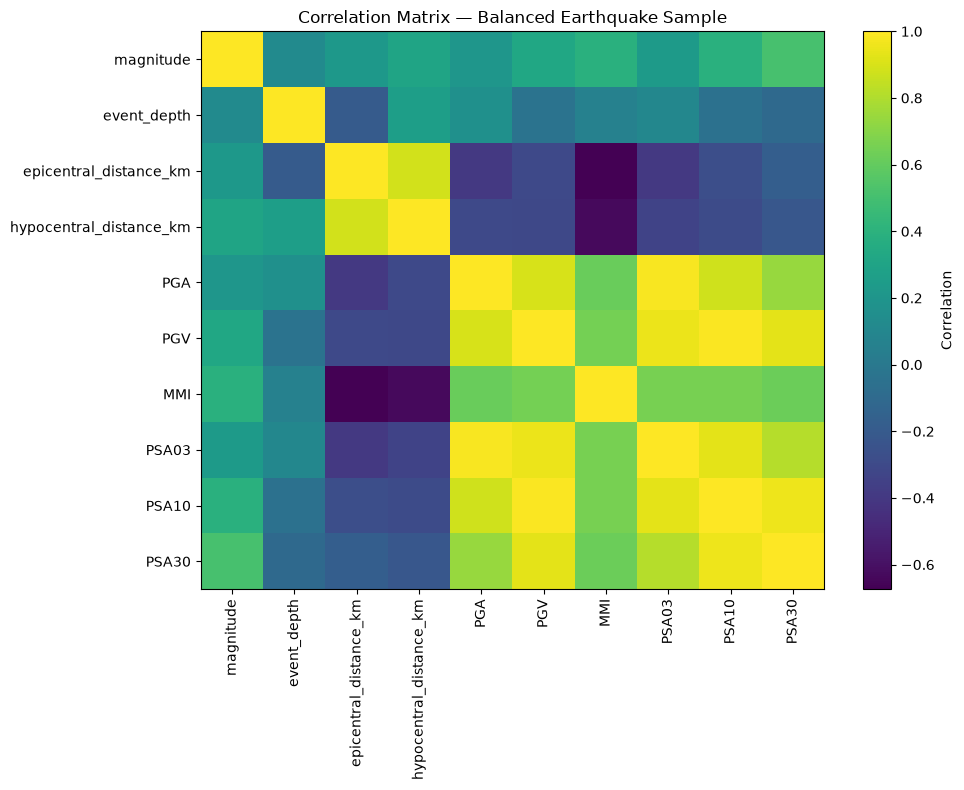

In [13]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title(
    "Correlation Matrix — Balanced Earthquake Sample"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "correlation_matrix.png",
    dpi=200
)

plt.show()

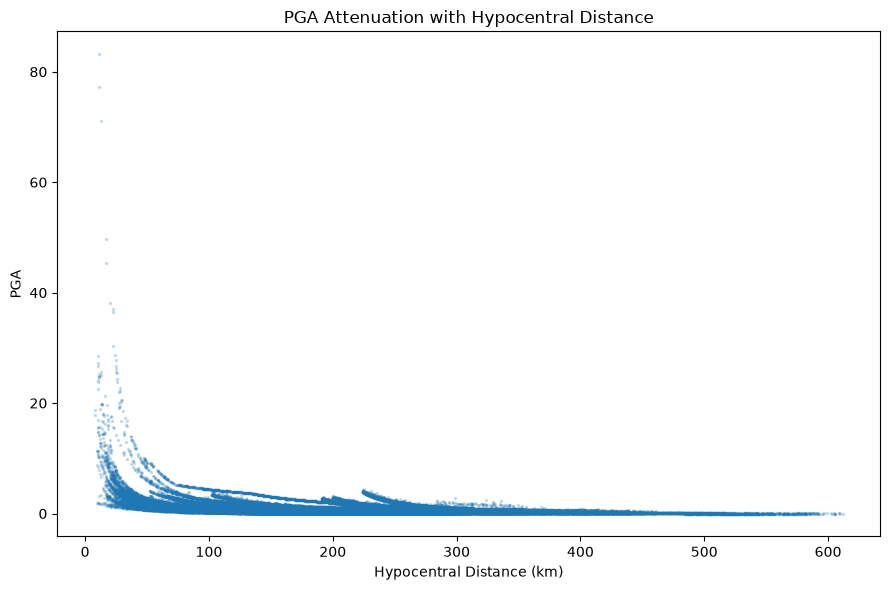

In [14]:
plot_sample = (
    balanced_sample
    .sample(
        n=min(
            100000,
            len(balanced_sample)
        ),
        random_state=42
    )
)

plt.figure(figsize=(9, 6))

plt.scatter(
    plot_sample["hypocentral_distance_km"],
    plot_sample["PGA"],
    s=2,
    alpha=0.2
)

plt.xlabel(
    "Hypocentral Distance (km)"
)

plt.ylabel(
    "PGA"
)

plt.title(
    "PGA Attenuation with Hypocentral Distance"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "pga_vs_distance.png",
    dpi=200
)

plt.show()

In [15]:
log_plot = plot_sample[
    (plot_sample["PGA"] > 0) &
    (plot_sample["hypocentral_distance_km"] > 0)
].copy()

log_plot["log_distance"] = np.log10(
    log_plot["hypocentral_distance_km"]
)

log_plot["log_pga"] = np.log10(
    log_plot["PGA"]
)

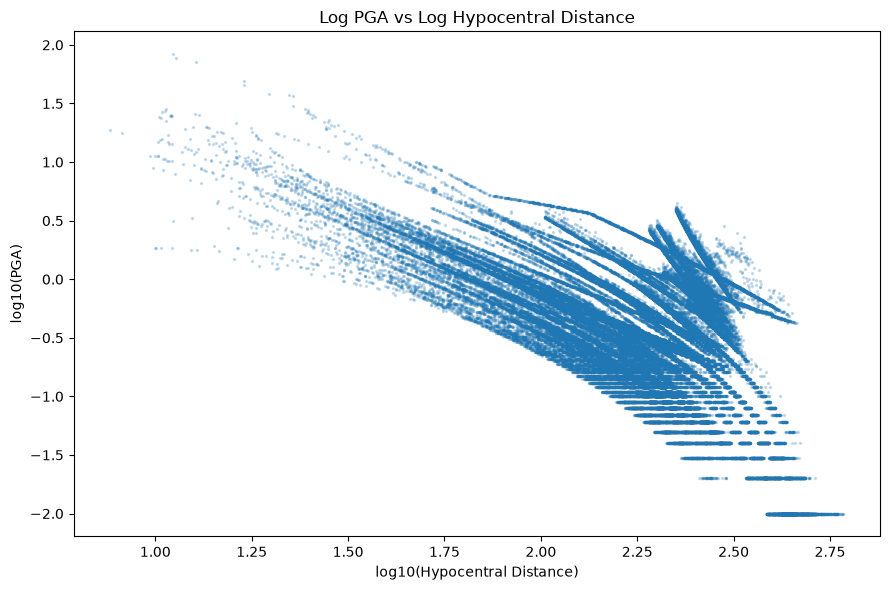

In [16]:
plt.figure(figsize=(9, 6))

plt.scatter(
    log_plot["log_distance"],
    log_plot["log_pga"],
    s=2,
    alpha=0.2
)

plt.xlabel(
    "log10(Hypocentral Distance)"
)

plt.ylabel(
    "log10(PGA)"
)

plt.title(
    "Log PGA vs Log Hypocentral Distance"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "log_pga_vs_log_distance.png",
    dpi=200
)

plt.show()

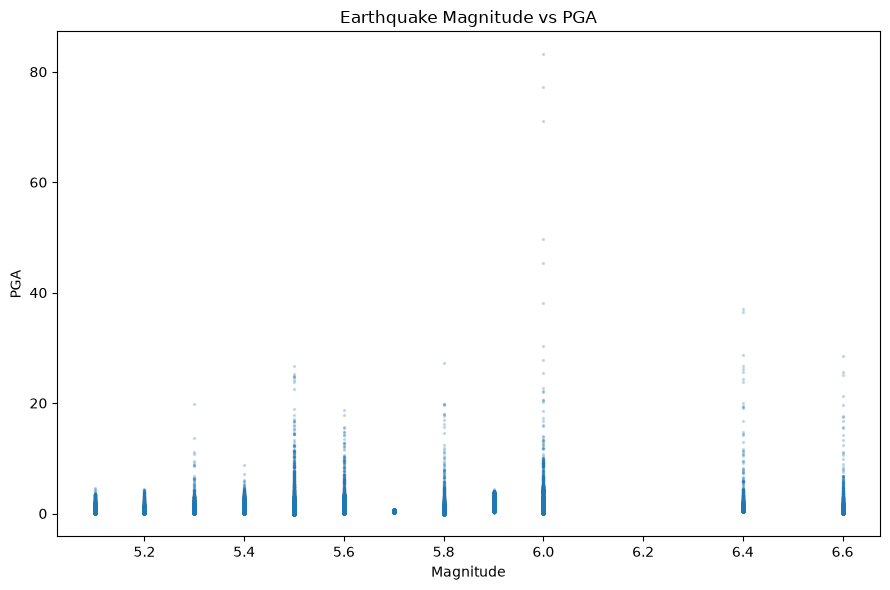

In [17]:
plt.figure(figsize=(9, 6))

plt.scatter(
    plot_sample["magnitude"],
    plot_sample["PGA"],
    s=2,
    alpha=0.2
)

plt.xlabel("Magnitude")
plt.ylabel("PGA")

plt.title(
    "Earthquake Magnitude vs PGA"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "magnitude_vs_pga.png",
    dpi=200
)

plt.show()

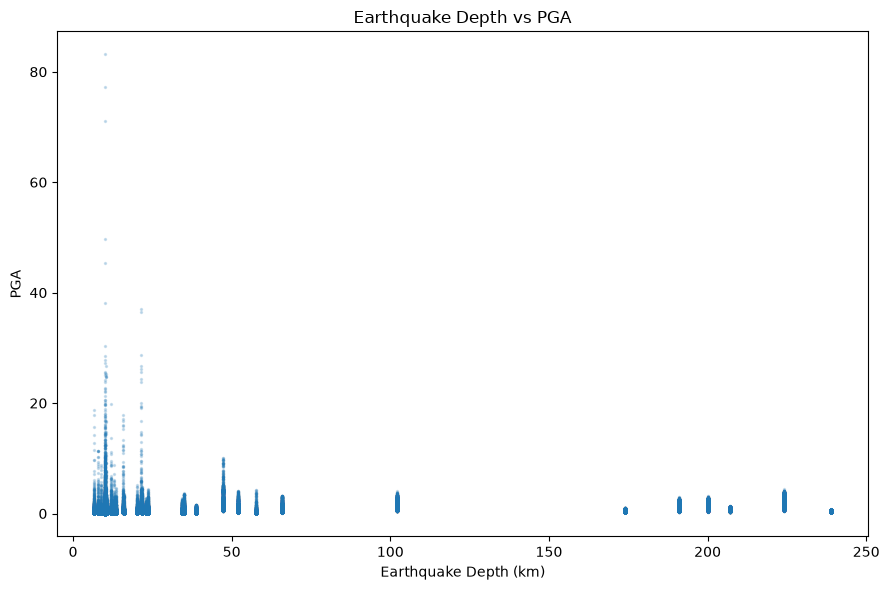

In [18]:
plt.figure(figsize=(9, 6))

plt.scatter(
    plot_sample["event_depth"],
    plot_sample["PGA"],
    s=2,
    alpha=0.2
)

plt.xlabel(
    "Earthquake Depth (km)"
)

plt.ylabel("PGA")

plt.title(
    "Earthquake Depth vs PGA"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "depth_vs_pga.png",
    dpi=200
)

plt.show()

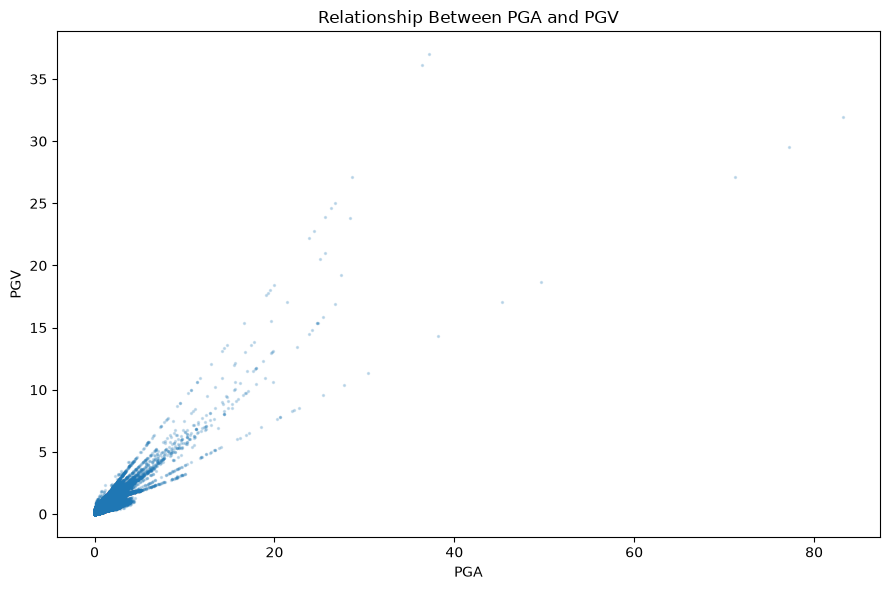

In [19]:
plt.figure(figsize=(9, 6))

plt.scatter(
    plot_sample["PGA"],
    plot_sample["PGV"],
    s=2,
    alpha=0.2
)

plt.xlabel("PGA")
plt.ylabel("PGV")

plt.title(
    "Relationship Between PGA and PGV"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "pga_vs_pgv.png",
    dpi=200
)

plt.show()

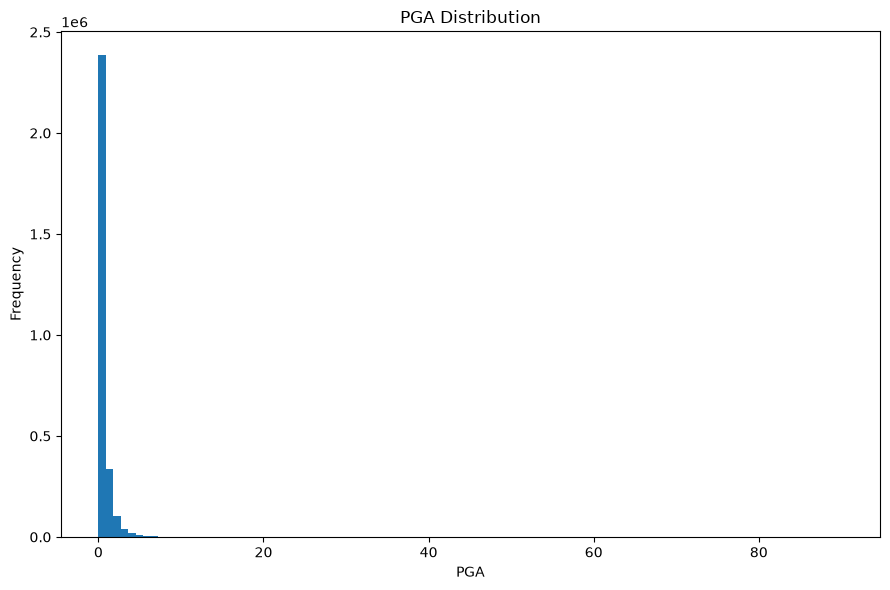

In [20]:
plt.figure(figsize=(9, 6))

plt.hist(
    dataset["PGA"].dropna(),
    bins=100
)

plt.xlabel("PGA")
plt.ylabel("Frequency")

plt.title(
    "PGA Distribution"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "pga_distribution.png",
    dpi=200
)

plt.show()

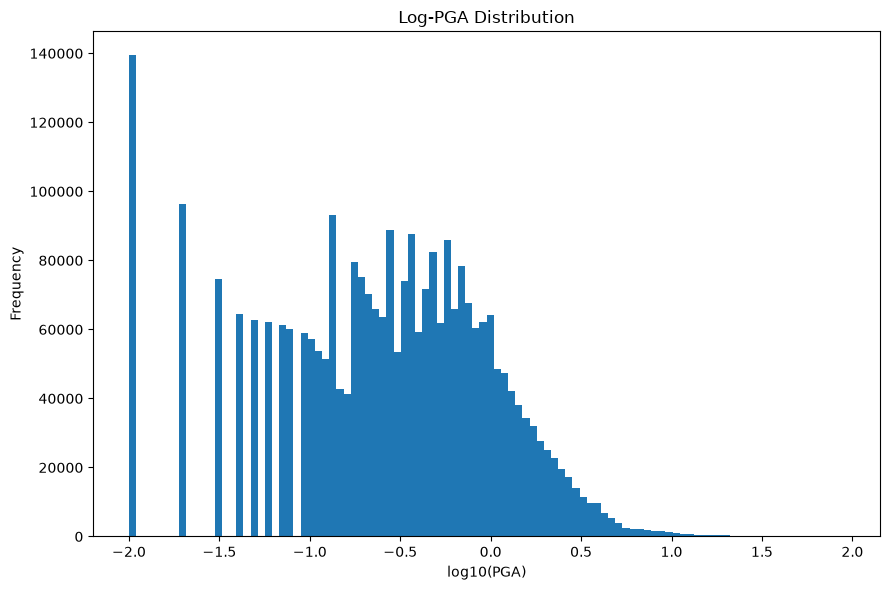

In [21]:
positive_pga = dataset.loc[
    dataset["PGA"] > 0,
    "PGA"
]

log_pga = np.log10(
    positive_pga
)

plt.figure(figsize=(9, 6))

plt.hist(
    log_pga,
    bins=100
)

plt.xlabel(
    "log10(PGA)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Log-PGA Distribution"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "log_pga_distribution.png",
    dpi=200
)

plt.show()

In [22]:
event_pga = (
    dataset
    .groupby("event_id")
    .agg(
        magnitude=("magnitude", "first"),
        depth_km=("event_depth", "first"),
        max_pga=("PGA", "max"),
        mean_pga=("PGA", "mean"),
        max_pgv=("PGV", "max")
    )
    .reset_index()
    .sort_values(
        "max_pga",
        ascending=False
    )
)

display(
    event_pga
)

,event_id,magnitude,depth_km,max_pga,mean_pga,max_pgv
28,us100088sf,6.0,10.00,90.17,0.859162,34.83
14,c000njrq,6.4,21.54,40.46,1.228739,41.44
21,us10003vry,6.6,10.00,29.13,0.828825,24.49
8,b000ryuh,5.8,10.00,29.01,0.906641,20.82
4,b000l2rk,5.5,10.26,26.96,0.684271,17.15
5,b000l4ju,5.5,15.61,26.91,0.667597,17.11
13,c000nb99,5.5,10.00,24.48,0.610760,14.99
15,c000njsg,5.5,10.00,24.48,0.610898,14.99
7,b000ry7u,5.3,12.00,21.42,0.482583,11.78
39,usc000syca,5.6,6.61,20.40,0.515496,13.58


In [23]:
display(
    event_pga.head(10)
)

,event_id,magnitude,depth_km,max_pga,mean_pga,max_pgv
28,us100088sf,6.0,10.00,90.17,0.859162,34.83
14,c000njrq,6.4,21.54,40.46,1.228739,41.44
21,us10003vry,6.6,10.00,29.13,0.828825,24.49
8,b000ryuh,5.8,10.00,29.01,0.906641,20.82
4,b000l2rk,5.5,10.26,26.96,0.684271,17.15
5,b000l4ju,5.5,15.61,26.91,0.667597,17.11
13,c000nb99,5.5,10.00,24.48,0.610760,14.99
15,c000njsg,5.5,10.00,24.48,0.610898,14.99
7,b000ry7u,5.3,12.00,21.42,0.482583,11.78
39,usc000syca,5.6,6.61,20.40,0.515496,13.58


In [24]:
spatial_extent = (
    dataset
    .groupby("event_id")
    .agg(
        min_lat=("grid_lat", "min"),
        max_lat=("grid_lat", "max"),
        min_lon=("grid_lon", "min"),
        max_lon=("grid_lon", "max"),
        observations=("event_id", "size")
    )
    .reset_index()
)

display(
    spatial_extent
)

,event_id,min_lat,max_lat,min_lon,max_lon,observations
0,b000fzn7,17.3590,21.1350,93.7410,97.7410,54948
1,b000g112,34.8470,38.0630,69.4710,73.4710,46754
2,b000hdu8,35.9250,39.0970,93.7940,97.7940,46031
3,b000ktbm,24.6198,28.2038,91.6451,95.6451,52056
4,b000l2rk,10.4435,14.3515,93.1481,97.1481,56635
5,b000l4ju,3.4296,7.4136,90.8184,94.8184,57840
6,b000qy82,15.3512,21.0512,85.0376,91.0376,123823
7,b000ry7u,12.4223,16.2983,91.0904,95.0904,56394
8,b000ryuh,10.4797,14.3877,93.2033,97.2033,56635
9,b000sfrw,25.5266,29.0826,63.7506,67.7506,51574


In [25]:
largest_event = (
    event_summary
    .sort_values(
        "magnitude",
        ascending=False
    )
    .iloc[0]["event_id"]
)

print(
    "Largest event:",
    largest_event
)

Largest event: us10003vry


In [26]:
largest_event_grid = dataset[
    dataset["event_id"] == largest_event
]

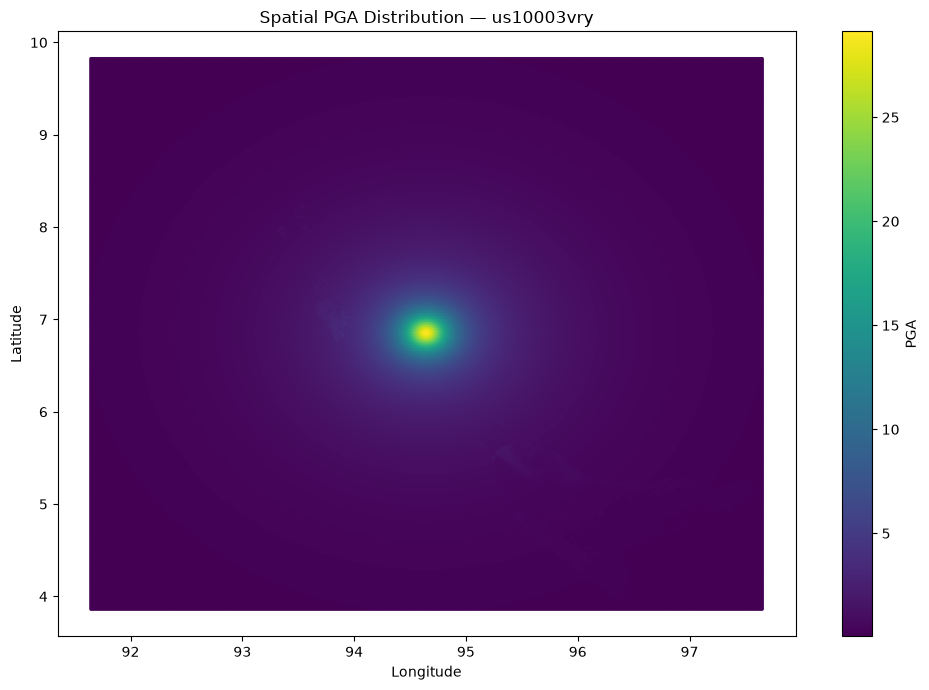

In [27]:
plt.figure(figsize=(10, 7))

plt.scatter(
    largest_event_grid["grid_lon"],
    largest_event_grid["grid_lat"],
    c=largest_event_grid["PGA"],
    s=3
)

plt.colorbar(
    label="PGA"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    f"Spatial PGA Distribution — {largest_event}"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "largest_event_pga_map.png",
    dpi=200
)

plt.show()

In [28]:
distance_bins = [
    0,
    25,
    50,
    100,
    150,
    200,
    300,
    400,
    500,
    700
]

dataset["distance_bin"] = pd.cut(
    dataset["hypocentral_distance_km"],
    bins=distance_bins
)

distance_summary = (
    dataset
    .groupby("distance_bin", observed=True)
    .agg(
        observations=("PGA", "size"),
        median_pga=("PGA", "median"),
        mean_pga=("PGA", "mean"),
        max_pga=("PGA", "max")
    )
    .reset_index()
)

display(distance_summary)

,distance_bin,observations,median_pga,mean_pga,max_pga
0,"(0, 25]",10761,7.15,10.037301,90.17
1,"(25, 50]",49737,2.47,3.424404,27.60
2,"(50, 100]",232466,1.01,1.447866,9.43
3,"(100, 150]",405879,0.48,0.744453,4.61
4,"(150, 200]",571866,0.28,0.441285,3.29
5,"(200, 300]",1006823,0.25,0.475585,4.97
6,"(300, 400]",374210,0.06,0.217993,2.57
7,"(400, 500]",203789,0.01,0.039767,1.00
8,"(500, 700]",57208,0.00,0.004208,0.02


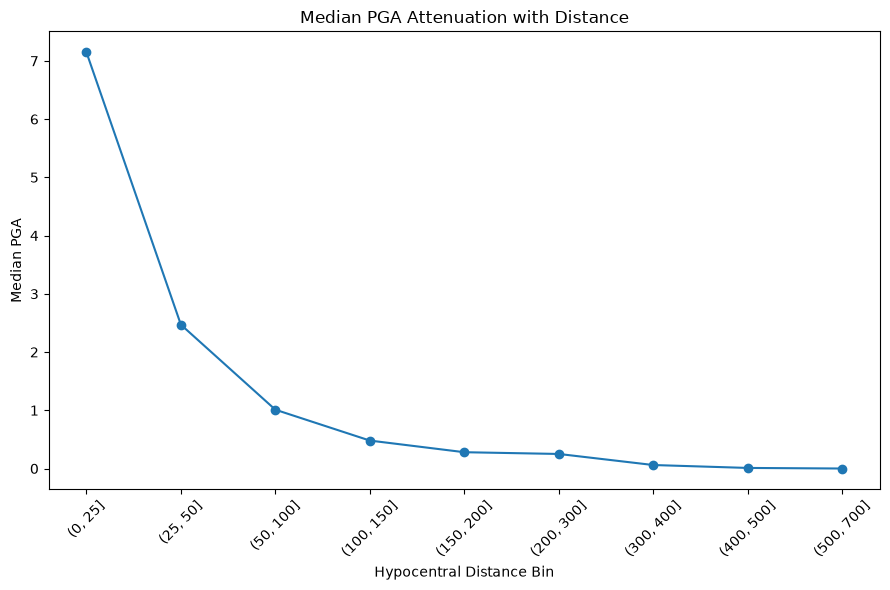

In [29]:
plt.figure(figsize=(9, 6))

plt.plot(
    distance_summary["distance_bin"].astype(str),
    distance_summary["median_pga"],
    marker="o"
)

plt.xticks(rotation=45)

plt.xlabel(
    "Hypocentral Distance Bin"
)

plt.ylabel(
    "Median PGA"
)

plt.title(
    "Median PGA Attenuation with Distance"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "median_pga_attenuation.png",
    dpi=200
)

plt.show()

In [30]:
event_counts = (
    dataset["event_id"]
    .value_counts()
    .sort_values()
)

display(
    event_counts.describe()
)

count        40.000000
mean      72818.475000
std       50548.553092
min       25277.000000
25%       46754.000000
50%       56514.500000
75%       57840.000000
max      228956.000000
Name: count, dtype: float64

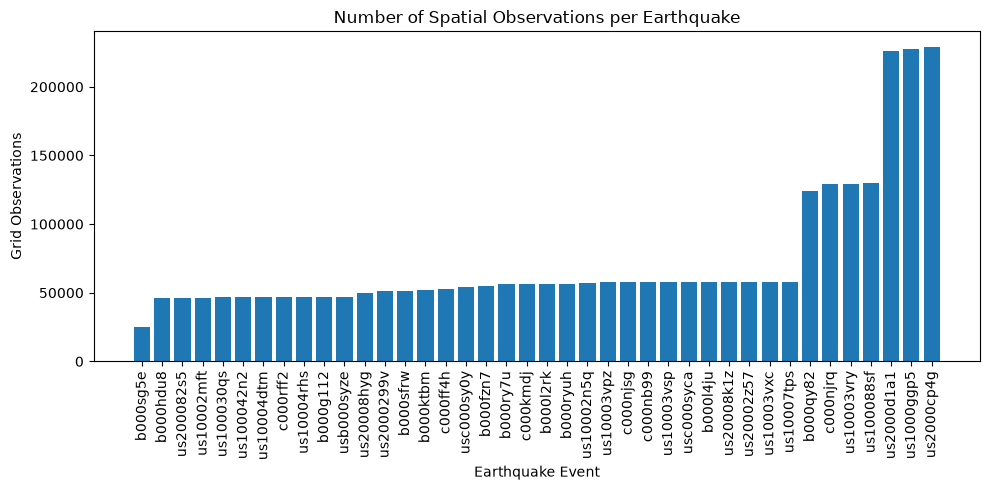

In [31]:
plt.figure(figsize=(10, 5))

plt.bar(
    event_counts.index,
    event_counts.values
)

plt.xticks(rotation=90)

plt.xlabel("Earthquake Event")
plt.ylabel("Grid Observations")

plt.title(
    "Number of Spatial Observations per Earthquake"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "event_observation_counts.png",
    dpi=200
)

plt.show()

In [32]:
event_summary.to_csv(
    PROCESSED_DIR /
    "event_level_summary.csv",
    index=False
)

distance_summary.to_csv(
    PROCESSED_DIR /
    "distance_attenuation_summary.csv",
    index=False
)

print("EDA summary files saved.")

EDA summary files saved.


In [34]:
balanced_sample.to_csv(
    PROCESSED_DIR /
    "balanced_eda_sample.csv",
    index=False
)

print(
    "Saved balanced EDA sample:",
    len(balanced_sample)
)

Saved balanced EDA sample: 200000
